In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from models.simple_vae import VAE
from models.mog_vae import MixtureVAE
import os
import imageio
import numpy as np
from scipy.stats import multivariate_normal


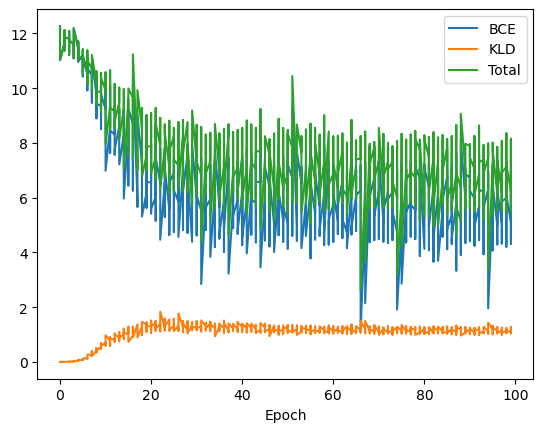

In [41]:
df = pd.read_csv('./logs/mixture_vae/trial_1.csv')
df['Total'] = df['BCE'] + df['KLD']
df.plot(x='Epoch', y=['BCE', 'KLD', 'Total'])
plt.show()

In [46]:
def plot_samples(samples, epoch, save_dir):
    # Grid for the contour plot
    x = np.linspace(-4, 4, 500)
    y = np.linspace(-4, 4, 500)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    # Bimodal Gaussian distribution
    mean1 = np.array([-1, -1])
    mean2 = np.array([-1, 1])
    mean3 = np.array([1, -1])
    mean4 = np.array([1, 1])

    cov = np.array([[.1, 0], [0, .1]])
    Z = 0.25*(multivariate_normal(mean1, cov).pdf(pos) + multivariate_normal(mean2, cov).pdf(pos) + multivariate_normal(mean3, cov).pdf(pos) + multivariate_normal(mean4, cov).pdf(pos))

    plt.figure(figsize=(10, 10))
    plt.contour(X, Y, Z, colors='r', alpha=0.5)  # True distribution in red
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)  # Model's distribution
                       
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)
    plt.title(f'Epoch {epoch}')
    plt.savefig(f'{save_dir}/tmp/scatter_{epoch}.png')
    plt.close()

model_dir = './results/saved_models/mixture_vae'
plot_dir = './results/plots'
os.makedirs(plot_dir, exist_ok=True)

images = []
epochs = 100
model = MixtureVAE(2, 2, 4)

for epoch in range(0, epochs):
    model_file = os.path.join(model_dir, f'model_{epoch}.pt')
    model.load_state_dict(torch.load(model_file))
    model.eval()
    
    z = torch.randn(10000, 2)
    with torch.no_grad():
        samples = model.decoder(z).numpy()
    
    plot_samples(samples, epoch, plot_dir)
    
    images.append(imageio.imread(f'{plot_dir}/tmp/scatter_{epoch}.png'))

# Save gif
imageio.mimsave(f'{plot_dir}/vae_mog_training.gif', images, duration=10)
!rm -rf ./results/plots/tmp/*.png

/var/folders/b_/x8lg97sd7512c9qf07myy77m0000gn/T/ipykernel_44690/2539174448.py:46: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(f'{plot_dir}/tmp/scatter_{epoch}.png'))
